### Video Understanding with Qwen2.5-VL

In this notebook, we delve into the capabilities of the **Qwen2.5-VL** model for video understanding tasks. Our objective is to showcase how this advanced model can be applied to various video analysis scenarios, ranging from basic OCR to complex event detection and summarization.


#### \[Setup\]

We start by loading the pre-trained `Qwen2_5_VLForConditionalGeneration` model. This model has been fine-tuned on a diverse set of video understanding tasks, enabling it to generate detailed and accurate descriptions based on visual inputs.


In [ ]:
# !pip uninstall transformers -y
# !pip install transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 9.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.0/468.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 13.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.0/462.0 kB 14.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 17.9 MB/s eta 0:00:00a 0:00:01


In [ ]:
# !pip install qwen_vl_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.7/38.7 MB 27.6 MB/s eta 0:00:0000:0100:01


In [1]:
import torch

print(torch.cuda.is_available())

ModuleNotFoundError: No module named 'torch'

In [ ]:
# !pip install flash_attn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 6.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.2 MB/s eta 0:00:00
  Created wheel for flash_attn: filename=flash_attn-2.7.4.post1-cp310-cp310-linux_x86_64.whl size=187696268 sha256=1776769f7ae3a8be3b31ec3a4c875ad1764da74be2d9b1751e5c01162ad0096f
  Stored in directory: /root/.cache/pip/wheels/59/ce/d5/08ea07bfc16ba218dc65a3a7ef9b6a270530bcbd2cea2ee1ca
Successfully built flash_attn
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.3.0
    Uninstalling typing_extensions-4.3.0:
      Successfully uninstalled typing_extensions-4.3.0


In [ ]:
# !pip install decord

  Using cached decord-0.6.0-py3-none-win_amd64.whl.metadata (422 bytes)
Using cached decord-0.6.0-py3-none-win_amd64.whl (24.7 MB)


In [ ]:
!huggingface-cli login

In [2]:
import torch
# VuthilinhVn/SFT-model2
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
!huggingface-cli scan-cache

⚠️  Warning: 'huggingface-cli scan-cache' is deprecated. Use 'hf cache scan' instead.
REPO ID                                                     REPO TYPE SIZE ON DISK NB FILES LAST_ACCESSED LAST_MODIFIED REFS   LOCAL PATH                                                                                               
----------------------------------------------------------- --------- ------------ -------- ------------- ------------- ------ -------------------------------------------------------------------------------------------------------- 
HuggingFaceM4/ChartQA                                       dataset         964.1M        6 3 days ago    3 weeks ago   main   C:\Users\APC\.cache\huggingface\hub\datasets--HuggingFaceM4--ChartQA                                     
bmd1905/vietnamese-correction-v2                            model             1.6G        6 3 days ago    1 week ago    main   C:\Users\APC\.cache\huggingface\hub\models--bmd1905--vietnamese-correction-v2           

In [ ]:
import torch
from transformers import BitsAndBytesConfig, Qwen3VLForConditionalGeneration , AutoProcessor
from qwen_vl_utils import process_vision_info

model_path = "Qwen/Qwen3-VL-4B-Instruct"
processor = AutoProcessor.from_pretrained(model_path)
# 7B -> 250 epoch >>> 3B -> duong nhien
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,     # Nested quantization → less VRAM
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
) # 8bit - quantized.
# Load model with flash attention
model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_path,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",  # Enable flash attention
    use_cache=True,
    quantization_config=bnb_config,
    dtype=torch.bfloat16,
)
processor = AutoProcessor.from_pretrained(model_path)

OSError: Qwen/Qwen3-VL-4B-Instruct is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

Load video frames and timestamps

In [ ]:
# Move the model to GPU
model.to("cuda")

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

In [ ]:
import os
import hashlib
import requests

from IPython.display import Markdown, display
import numpy as np
from PIL import Image
import decord
from decord import VideoReader, cpu


def download_video(url, dest_path):
    response = requests.get(url, stream=True)
    with open(dest_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8096):
            f.write(chunk)
    print(f"Video downloaded to {dest_path}")


def get_video_frames(video_path, num_frames=128, cache_dir='.cache'):
    os.makedirs(cache_dir, exist_ok=True)

    video_hash = hashlib.md5(video_path.encode('utf-8')).hexdigest()
    if video_path.startswith('http://') or video_path.startswith('https://'):
        video_file_path = os.path.join(cache_dir, f'{video_hash}.mp4')
        if not os.path.exists(video_file_path):
            download_video(video_path, video_file_path)
    else:
        video_file_path = video_path

    frames_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_frames.npy')
    timestamps_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_timestamps.npy')

    if os.path.exists(frames_cache_file) and os.path.exists(timestamps_cache_file):
        frames = np.load(frames_cache_file)
        timestamps = np.load(timestamps_cache_file)
        return video_file_path, frames, timestamps

    vr = VideoReader(video_file_path, ctx=cpu(0))
    total_frames = len(vr)

    indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    frames = vr.get_batch(indices).asnumpy()
    timestamps = np.array([vr.get_frame_timestamp(idx) for idx in indices])

    np.save(frames_cache_file, frames)
    np.save(timestamps_cache_file, timestamps)

    return video_file_path, frames, timestamps


def create_image_grid(images, num_columns=8):
    pil_images = [Image.fromarray(image) for image in images]
    num_rows = (len(images) + num_columns - 1) // num_columns

    img_width, img_height = pil_images[0].size
    grid_width = num_columns * img_width
    grid_height = num_rows * img_height
    grid_image = Image.new('RGB', (grid_width, grid_height))

    for idx, image in enumerate(pil_images):
        row_idx = idx // num_columns
        col_idx = idx % num_columns
        position = (col_idx * img_width, row_idx * img_height)
        grid_image.paste(image, position)

    return grid_image


Inference function

In [ ]:
def inference(video_path, prompt, max_new_tokens=2048, total_pixels=20480 * 28 * 28, min_pixels=16 * 28 * 28):
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": [
                {"type": "text", "text": prompt},
                {"video": video_path, "total_pixels": total_pixels, "min_pixels": min_pixels},
            ]
        },
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs, video_kwargs = process_vision_info([messages], return_video_kwargs=True)
    fps_inputs = video_kwargs['fps'][0]
    print("video input:", video_inputs[0].shape)
    num_frames, _, resized_height, resized_width = video_inputs[0].shape
    print("num of video tokens:", int(num_frames / 2 * resized_height / 28 * resized_width / 28))
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, fps=fps_inputs, padding=True, return_tensors="pt")
    inputs = inputs.to('cuda')

    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, output_ids)]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    return output_text[0]

## Test Inference

#### 1. Reading Text in Videos

In this section, we demonstrate how the model can be used to recognize and summarize text within a video. Specifically, we'll use a video containing various products and ask the model to summarize their characteristics in a structured format.


In [ ]:
video_url = "https://duguang-labelling.oss-cn-shanghai.aliyuncs.com/qiansun/video_ocr/videos/50221078283.mp4"
prompt = "请用表格总结一下视频中的商品特点" # Summarize the table

video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
# image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))

response = inference(video_path, prompt)
display(Markdown(response))


video input: torch.Size([58, 3, 532, 980])
num of video tokens: 19285


以下是根据视频内容制作的表格：

| 序号 | 特点描述                                                                 |
| ---- | ---------------------------------------------------------------------- |
| 1    | 龙眼、切片西瓜、圣女果、樱桃等。                                      |
| 2    | 人性化设计，易扣不繁琐。                                              |
| 3    | 上下盖紧锁，摇晃不脱落。                                             |
| 4    | 采用PET材料制作，做工精细。                                         |
| 5    | 防压抗摔，耐压耐磨，耐低温，可冷藏。                                 |
| 6    | 可承受12斤红砖，运输过程不会损坏。                                  |
| 7    | 纹理清晰质感佳，形状好，光泽度好。                                   |
| 8    | 高透加厚，盒内产品一目了然，无色无味。                               |
| 9    | 全面展示。                                                              |

希望这个表格能帮助你更好地理解视频中的商品特点。

In [ ]:
frames

#### 2. Long Video Understanding

Next, we explore the model's capability to comprehend extremely long videos, such as those lasting up to one hour. This demonstrates how the model can effectively process and analyze extended video content, extracting meaningful insights over longer durations.

To reduce the number of visual tokens generated from a long video, you can specify the `resized_height` and `resized_width` parameters. These settings allow the video frames to be resized to a smaller dimension, effectively decreasing the computational load while maintaining the essential visual information needed for analysis.


In [ ]:
video_url = "https://ofasys-multimodal-wlcb-3.oss-cn-wulanchabu.aliyuncs.com/sibo.ssb/evaluations/data/LVBench/videos/GcRKREorGSc.mp4"
prompt = "Could you go into detail about the content of this long video?"

video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
# image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))

response = inference(video_path, prompt)
display(Markdown(response))


Video downloaded to .cache\7d4f2124d00694069a87082caf74b63b.mp4
video input: torch.Size([768, 3, 140, 252])
num of video tokens: 17280


The video is a beautiful and serene depiction of the African savanna, showcasing the diverse wildlife that inhabits this vast landscape. The opening scenes set the stage with a panoramic view of the savanna, featuring expansive grasslands, scattered trees, and a clear blue sky dotted with fluffy white clouds. This tranquil setting sets the tone for the natural beauty and tranquility of the environment.

As the video progresses, it transitions to various scenes of wildlife. The first notable scene captures a majestic lion walking through the grasslands, its powerful presence highlighted by the lush greenery surrounding it. The lion's movements are graceful and deliberate, embodying the strength and grace of these magnificent creatures. The camera then shifts focus to other animals, including a group of zebras grazing peacefully in the distance. Their black and white stripes contrast beautifully against the green grass, creating a visually striking image.

The video also highlights the intricate details of the savanna ecosystem. Scenes of birds perched on branches, such as the yellow-billed hornbill, add vibrant pops of color to the natural palette. These birds, with their bright yellow beaks and feathers, provide a stark yet harmonious contrast to the more subdued tones of the savanna.

Another captivating moment showcases a group of elephants walking through the grasslands. Their massive size and gentle demeanor are evident as they move slowly across the landscape, emphasizing the scale and majesty of these creatures. The elephants' presence adds a sense of depth and scale to the savanna, highlighting the interconnectedness of the ecosystem.

The video further explores the diversity of wildlife, featuring scenes of leopards and cheetahs hunting in the grasslands. The leopards, with their sleek coats and sharp eyes, stalk their prey with precision, while the cheetahs, with their agile bodies, chase after their prey with incredible speed. These scenes capture the raw energy and excitement of the savanna, showcasing the relentless pursuit and survival instincts of these predators.

The video also delves into the social dynamics of the savanna. Scenes of gazelles grazing together and interacting with each other highlight the cooperative nature of these animals. The gazelles' synchronized movements and interactions demonstrate the importance of community and cooperation in the wild.

In addition to the wildlife, the video captures the beauty of the savanna's flora. Scenes of trees and bushes dotting the landscape showcase the variety of vegetation that supports the diverse wildlife. The lush greenery provides a rich habitat for insects, birds, and other small animals, contributing to the overall biodiversity of the ecosystem.

The video concludes with a serene sunset scene, where the sky transitions from warm oranges and pinks to cool blues and purples. The sun dips below the horizon, casting a golden glow over the landscape. This final scene encapsulates the peaceful and tranquil essence of the savanna, providing a fitting end to the visual journey.

Overall, the video is a breathtaking portrayal of the African savanna, capturing the beauty, diversity, and complexity of the natural world. It highlights the interconnectedness of the ecosystem, showcasing the resilience and adaptability of the wildlife that call this vast landscape home. The serene and tranquil atmosphere of the savanna, coupled with the stunning visuals of the wildlife, creates a lasting impression of the African wilderness.

#### 3. Video Grounding

This part focuses on answering specific questions about a video segment. We specify a textual query and ask the model what is the period that the described content occur in the video, showcasing the model's ability to understand timestamps and search the detailed queries.

Video downloaded to .cache\6949e7065425b86c463a4c8fb6abf98e.mp4


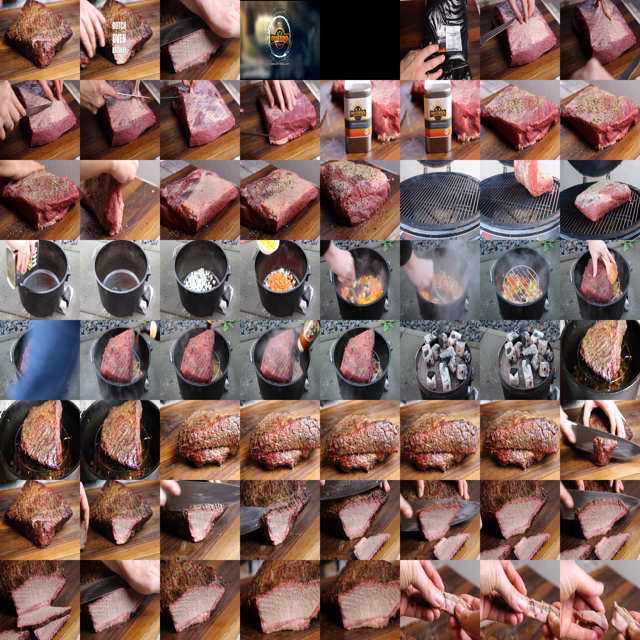

video input: torch.Size([530, 3, 168, 308])
num of video tokens: 17490


The query "seasoning the steak" occurs in the middle of the video, specifically around 30 seconds into the cooking process.

In [21]:
video_url = "https://ofasys-multimodal-wlcb-3.oss-cn-wulanchabu.aliyuncs.com/sibo.ssb/datasets/cookbook/ead2e3f0e7f836c9ec51236befdaf2d843ac13a6.mp4"
prompt = "Give the query: 'seasoning the steak', when does the described content occur in the video?"

video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
image_grid = create_image_grid(frames, num_columns=8)
display(image_grid.resize((640, 640)))

# inference
response = inference(video_path, prompt)
display(Markdown(response))

#### 4. Structured Video Captioning

Finally, we present a scenario where the model identifies significant events within the video, providing start and end timestamps for each event along with descriptive sentences. The output is formatted in JSON for easy parsing and further processing.


In [22]:
video_url = "https://ofasys-multimodal-wlcb-3.oss-cn-wulanchabu.aliyuncs.com/sibo.ssb/datasets/cookbook/ead2e3f0e7f836c9ec51236befdaf2d843ac13a6.mp4"
prompt = "Localize a series of activity events in the video, output the start and end timestamp for each event, and describe each event with sentences. Provide the result in json format with 'mm:ss.ff' format for time depiction."

video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
# image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))

In [ ]:
# inference
response = inference(video_path, prompt) # video path là path tới từng FRAME
display(Markdown(response))

video input: torch.Size([530, 3, 168, 308])
num of video tokens: 17490


KeyboardInterrupt: 

- By post-processing the json results, we can intuitively present video clips and descriptions in an interleaved manner.

In [ ]:
!pip install markdown

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 463.3 kB/s eta 0:00:000:00:01


In [ ]:
import json
import markdown
from bs4 import BeautifulSoup
from datetime import datetime


def parse_json(response):
    html = markdown.markdown(response, extensions=['fenced_code'])
    soup = BeautifulSoup(html, 'html.parser')
    json_text = soup.find('code').text

    data = json.loads(json_text)
    return data


def time_to_seconds(time_str):
    time_obj = datetime.strptime(time_str, '%M:%S.%f')
    total_seconds = time_obj.minute * 60 + time_obj.second + time_obj.microsecond / 1_000_000
    return total_seconds


**00:00.00 - 00:25.60:**		A person is slicing a piece of meat on a cutting board.

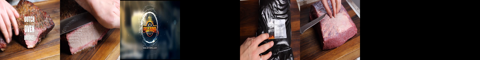

**00:25.60 - 01:37.80:**		The person is seasoning a large piece of meat with salt and pepper.

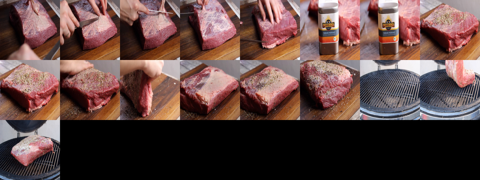

**01:37.80 - 02:49.20:**		The person is putting the seasoned meat on a grill and cooking vegetables in a pot.

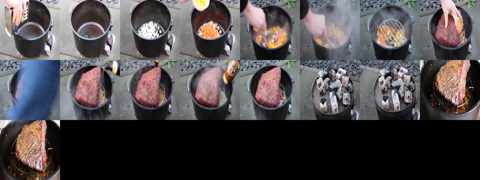

**02:49.20 - 03:59.80:**		The person is putting the meat into the pot with the vegetables and cooking it.

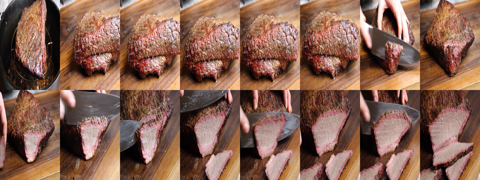

In [ ]:
data = parse_json(response)

for item in data:
    start_time = item["start_time"]
    end_time = item["end_time"]
    description = item["description"]

    display(Markdown(f"**{start_time} - {end_time}:**\t\t" + description))

    start_time = time_to_seconds(start_time)
    end_time = time_to_seconds(end_time)
    current_frames = []
    for frame, timestamp in zip(frames, timestamps):
        if timestamp[0] > start_time and timestamp[1] < end_time:
            current_frames.append(frame)

    current_frames = np.array(current_frames)
    current_image_grid = create_image_grid(current_frames, num_columns=8)

    display(current_image_grid.resize((480, (int(len(current_frames) / 8) + 1) * 60)))


In [ ]:
# https://drive.google.com/uc?export=download&id=1Xfp31965Jqlf_554IyNwseYgkdMCu4r0

In [ ]:
video_url = "https://drive.google.com/uc?export=download&id=1Xfp31965Jqlf_554IyNwseYgkdMCu4r0"
prompt = "Localize a series of activity events in the video, output the start and end timestamp for each event, and describe each event with sentences. Provide the result in json format with 'mm:ss.ff' format for time depiction."

video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)

# inference
response = inference(video_path, prompt)
display(Markdown(response))

Video downloaded to .cache/b4d0faed3249d6cdef33cbc58a77fd61.mp4
video input: torch.Size([768, 3, 140, 252])
num of video tokens: 17280


```json
[
    {
        "start_time": "00:00:00.00",
        "end_time": "00:00:19.00",
        "description": "The video begins with a discussion about integrating large language models into local systems using Ollama. The speaker mentions the availability of a private GPT to chat with documents and the ability to ask questions using a technology known as private GPT."
    },
    {
        "start_time": "00:00:19.00",
        "end_time": "00:00:37.00",
        "description": "The speaker introduces the concept of using Ollama to power a private GPT that can be used to chat with documents. They mention the need to install Ollama on a system and provide a link to download it."
    },
    {
        "start_time": "00:00:37.00",
        "end_time": "00:00:58.00",
        "description": "The speaker discusses the process of installing Ollama and mentions receiving comments from viewers asking how to upload CSV files and ask questions. They explain that they will demonstrate this process in the video."
    },
    {
        "start_time": "00:00:58.00",
        "end_time": "00:01:16.00",
        "description": "The speaker explains that they will start by setting up the private GPT and mentions that they have already installed Ollama. They introduce the concept of using Ollama to power the private GPT."
    },
    {
        "start_time": "00:01:16.00",
        "end_time": "00:01:34.00",
        "description": "The speaker continues discussing the installation of Ollama and mentions that they will use it to power the private GPT. They explain that they will need to install Ollama on their system."
    },
    {
        "start_time": "00:01:34.00",
        "end_time": "00:01:52.00",
        "description": "The speaker provides a link to download Ollama and mentions that it is still available. They explain that once downloaded, they will need to sign in to continue."
    },
    {
        "start_time": "00:01:52.00",
        "end_time": "00:02:10.00",
        "description": "The speaker navigates to the Ollama website and clicks on the download button. They mention that they will now open the terminal and run the command to install Ollama."
    },
    {
        "start_time": "00:02:10.00",
        "end_time": "00:02:28.00",
        "description": "The speaker opens the terminal and runs the command to install Ollama. They mention that they will use the Mistral model for chatting and provide an example of a job interview question."
    },
    {
        "start_time": "00:02:28.00",
        "end_time": "00:02:46.00",
        "description": "The speaker demonstrates the installation of Ollama and shows the terminal output. They mention that they will now exit the terminal and return to the Ollama website."
    },
    {
        "start_time": "00:02:46.00",
        "end_time": "00:03:04.00",
        "description": "The speaker returns to the Ollama website and navigates to the GitHub repository. They mention that they will integrate the private GPT with Ollama and provide a link to the repository."
    },
    {
        "start_time": "00:03:04.00",
        "end_time": "00:03:22.00",
        "description": "The speaker navigates to the GitHub repository and searches for the private GPT. They mention that they will show the integration process and provide a link to the repository."
    },
    {
        "start_time": "00:03:22.00",
        "end_time": "00:03:40.00",
        "description": "The speaker navigates to the GitHub repository and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:03:40.00",
        "end_time": "00:03:58.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:03:58.00",
        "end_time": "00:04:16.00",
        "description": "The speaker navigates to the Ollama website and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:04:16.00",
        "end_time": "00:04:34.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:04:34.00",
        "end_time": "00:04:52.00",
        "description": "The speaker navigates to the Ollama website and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:04:52.00",
        "end_time": "00:05:10.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:05:10.00",
        "end_time": "00:05:28.00",
        "description": "The speaker navigates to the Ollama website and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:05:28.00",
        "end_time": "00:05:46.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:05:46.00",
        "end_time": "00:06:04.00",
        "description": "The speaker navigates to the Ollama website and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:06:04.00",
        "end_time": "00:06:22.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:06:22.00",
        "end_time": "00:06:40.00",
        "description": "The speaker navigates to the Ollama website and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:06:40.00",
        "end_time": "00:06:58.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:06:58.00",
        "end_time": "00:07:16.00",
        "description": "The speaker navigates to the Ollama website and shows the integration process. They mention that they will now go to the pinned repository and show the code."
    },
    {
        "start_time": "00:07:16.00",
        "end_time": "00:07:34.00",
        "description": "The speaker navigates to the pinned repository and shows the code. They mention that they will now go to the Ollama website and show the integration process."
    },
    {
        "start_time": "00:07:34.00",
        "end_time": "00:07:52.00",
        "description": "The speaker navigates to the Oll